# Space X Falcon 9 First Stage Landing Prediction
## Lab 4: Exploratory data analysis and feature engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
                 "IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


### Flight Number vs Payload Mass

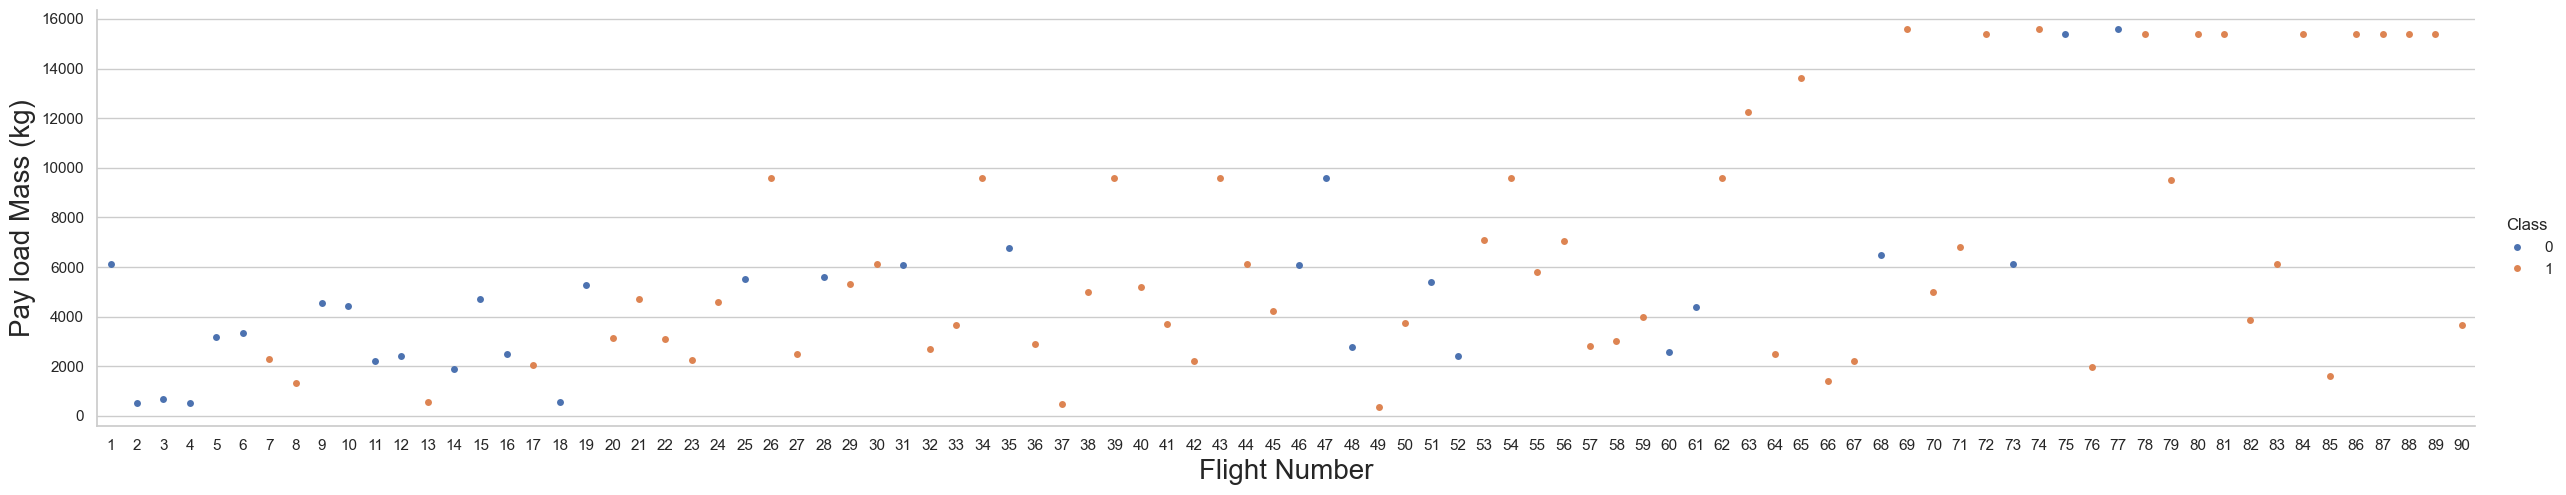

In [3]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Pay load Mass (kg)", fontsize=20)
plt.show()

### TASK 1: Visualize the relationship between Flight Number and Launch Site

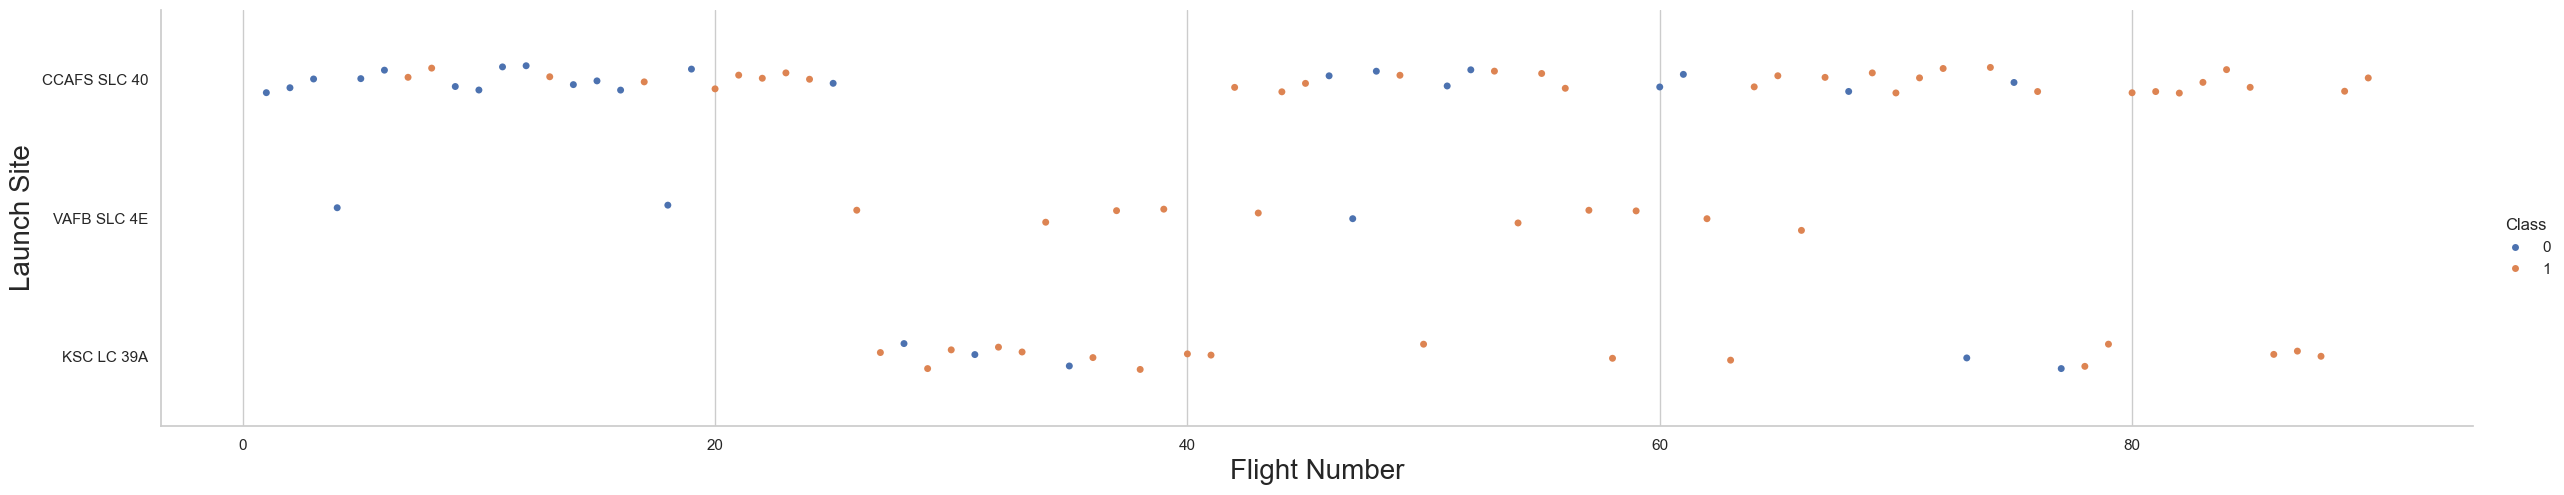

In [4]:
sns.catplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.show()

### TASK 2: Visualize the relationship between Payload Mass and Launch Site

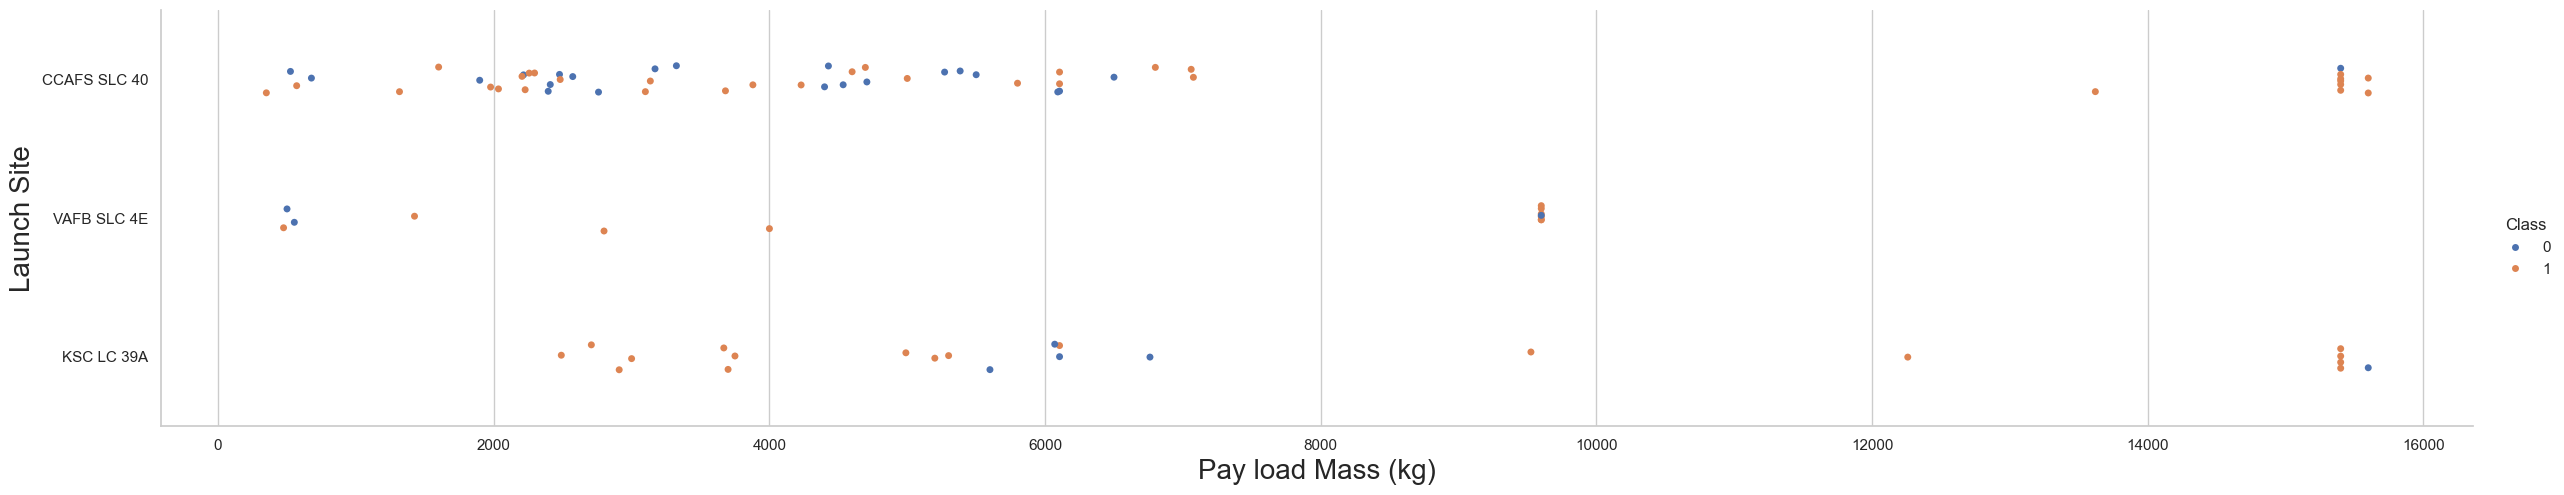

In [5]:
sns.catplot(y="LaunchSite", x="PayloadMass", hue="Class", data=df, aspect=5)
plt.xlabel("Pay load Mass (kg)", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.show()

### TASK 3: Visualize the relationship between success rate of each orbit type

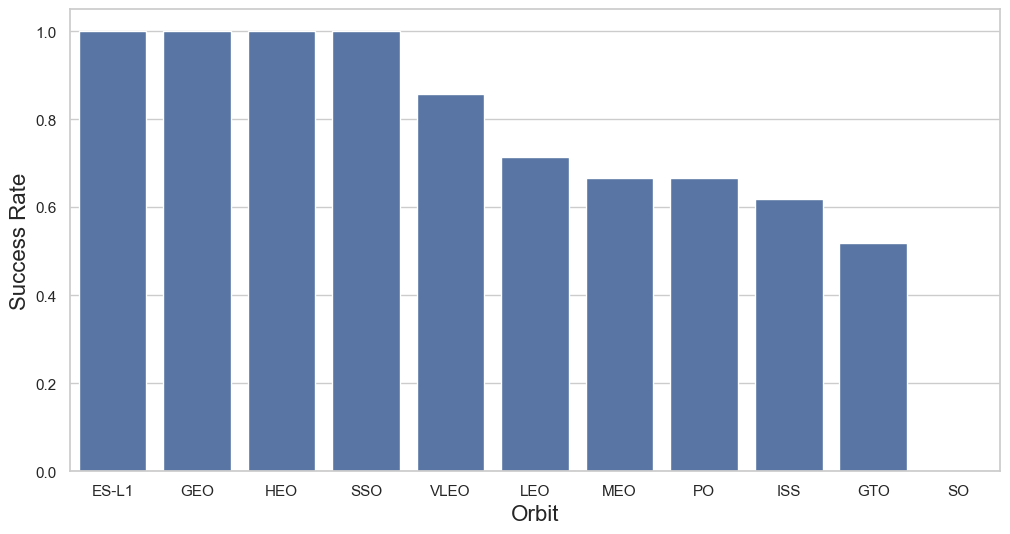

Orbit
ES-L1    1.000000
GEO      1.000000
HEO      1.000000
SSO      1.000000
VLEO     0.857143
LEO      0.714286
MEO      0.666667
PO       0.666667
ISS      0.619048
GTO      0.518519
SO       0.000000
Name: Class, dtype: float64

In [6]:
orbit_success = df.groupby('Orbit')['Class'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=orbit_success.index, y=orbit_success.values)
plt.xlabel("Orbit", fontsize=16)
plt.ylabel("Success Rate", fontsize=16)
plt.show()
orbit_success

### TASK 4: Visualize the relationship between FlightNumber and Orbit type

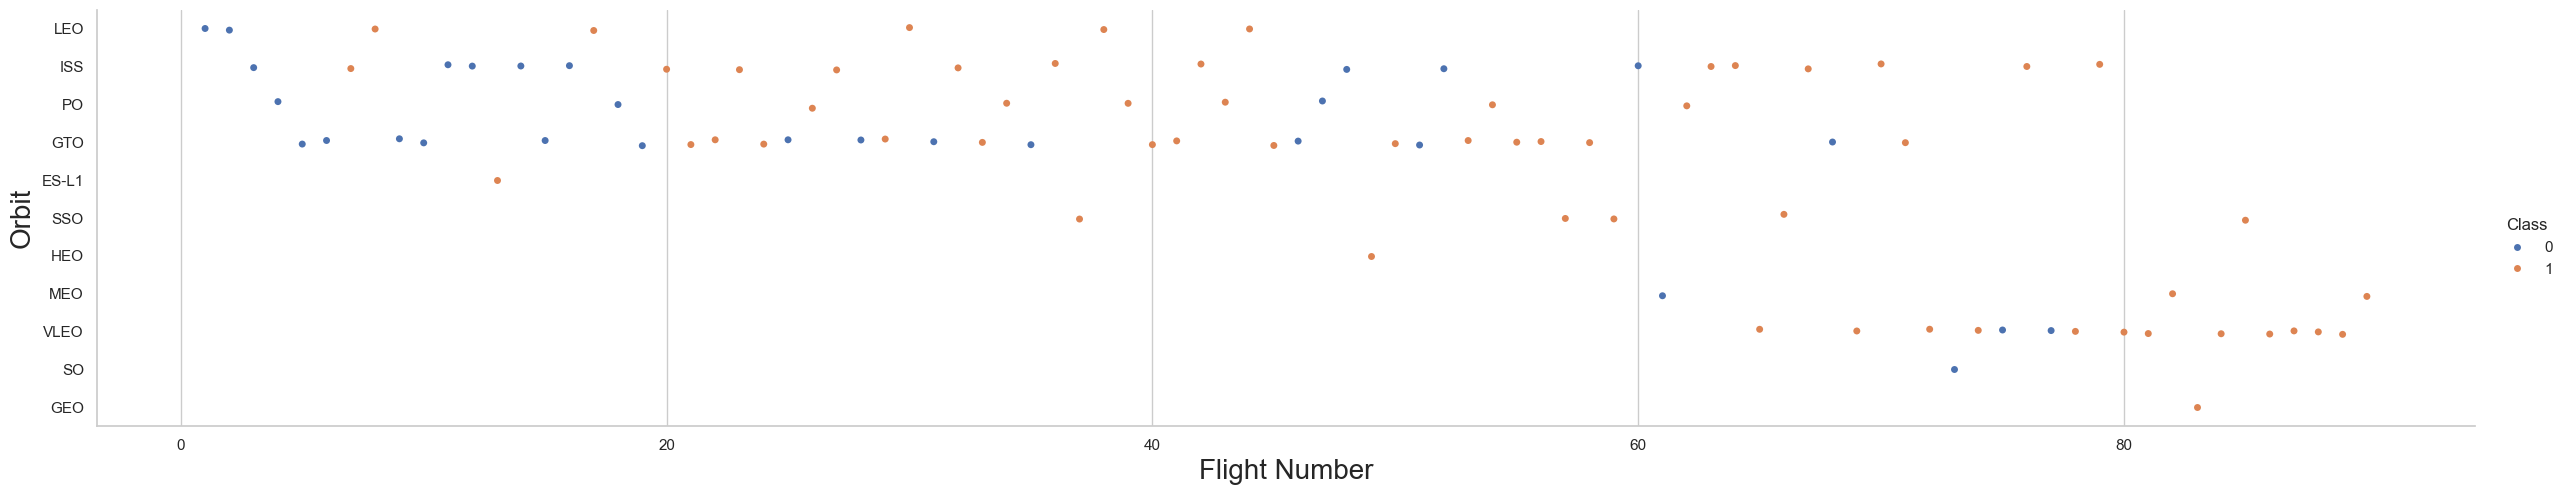

In [7]:
sns.catplot(y="Orbit", x="FlightNumber", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Orbit", fontsize=20)
plt.show()

### TASK 5: Visualize the relationship between Payload Mass and Orbit type

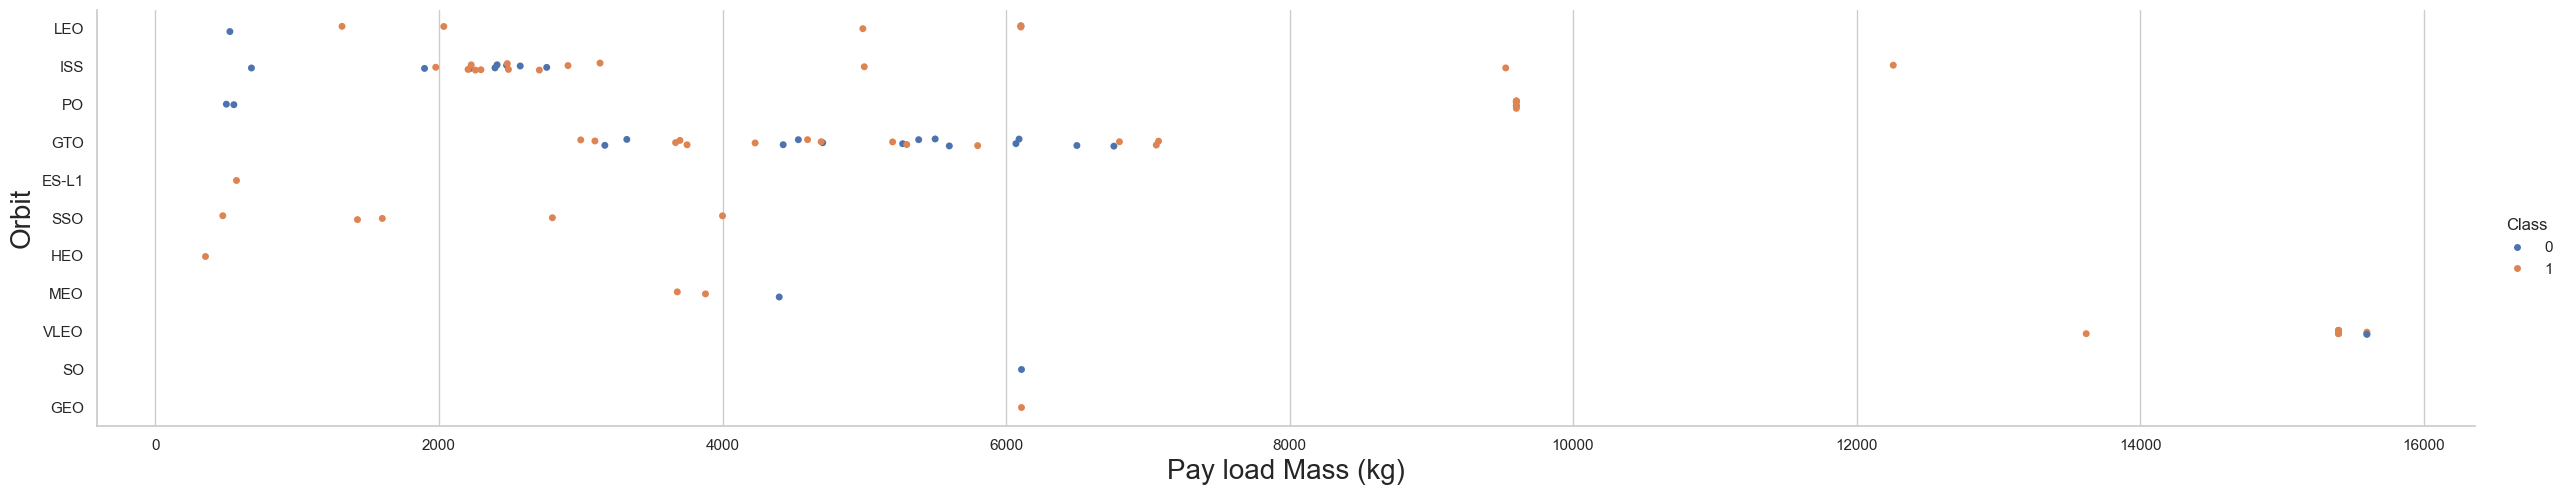

In [8]:
sns.catplot(y="Orbit", x="PayloadMass", hue="Class", data=df, aspect=5)
plt.xlabel("Pay load Mass (kg)", fontsize=20)
plt.ylabel("Orbit", fontsize=20)
plt.show()

### TASK 6: Visualize the launch success yearly trend

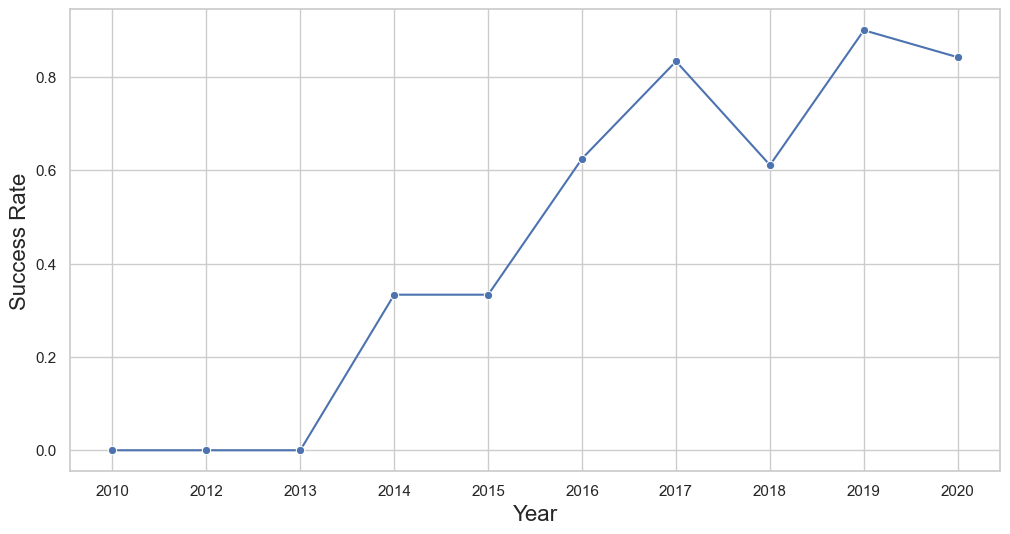

,Year,Class
0,2010,0.000000
1,2012,0.000000
2,2013,0.000000
3,2014,0.333333
4,2015,0.333333
5,2016,0.625000
6,2017,0.833333
7,2018,0.611111
8,2019,0.900000
9,2020,0.842105


In [9]:
def Extract_year(dates):
    return [i.split("-")[0] for i in dates]

df['Year'] = Extract_year(df['Date'])
yearly = df.groupby('Year')['Class'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Class', data=yearly, marker='o')
plt.xlabel("Year", fontsize=16)
plt.ylabel("Success Rate", fontsize=16)
plt.show()
yearly

### Features Engineering

In [10]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights',
                'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount',
                'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### TASK 7: Create dummy variables to categorical columns

In [11]:
features_one_hot = pd.get_dummies(features,
                                  columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
print("shape after one hot encoding:", features_one_hot.shape)
features_one_hot.head()

shape after one hot encoding: (90, 80)


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


### TASK 8: Cast all numeric columns to float64

In [12]:
features_one_hot = features_one_hot.astype('float64')
features_one_hot.dtypes.value_counts()

float64    80
Name: count, dtype: int64

In [13]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)
print("saved dataset_part_3.csv")

saved dataset_part_3.csv
